# Latent Factors Intuition

## Роль notebook

Это короткий теоретический мост между `item-item CF` из `core` и `ALS` из `advanced`.
Здесь не нужно сразу обучать полноценную модель на реальном датасете.
Главная цель: сделать идею latent factors интуитивной до кода библиотек и full-scale оптимизации.

## План

- взять маленькую toy user-item матрицу;
- показать, почему похожесть по соседям не единственный способ описывать предпочтения;
- ввести идею скрытых факторов пользователя и объекта;
- связать score пользователя и объекта с dot product их latent-представлений;
- показать, как low-rank factorization автоматически приближает ту же идею;
- подготовить почву для `01_als_implicit.ipynb`.

## Validation checklist

- notebook остаётся маленьким и теоретическим;
- нет лишней инфраструктуры и тяжёлых зависимостей;
- после него новичку понятно, зачем вообще нужен factorization-подход;
- переход к `ALS` выглядит естественно, а не резким.


## 1. Маленькая toy interaction matrix

Возьмём игрушечный пример с бинарными предпочтениями.
Здесь `1` означает: пользователю объект явно нравится или он уже взаимодействовал с ним позитивно.

Важно: это **не production-данные** и не честная offline-оценка.
Это только маленькая матрица, на которой удобно увидеть структуру предпочтений.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

plt.style.use("ggplot")
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


In [2]:
users = ["Alice", "Bob", "Carol", "Dave", "Eve"]
items = ["Toy Story", "Monsters, Inc.", "The Matrix", "John Wick", "Mad Max"]

interactions = pd.DataFrame(
    [
        [1, 1, 0, 0, 0],
        [0, 0, 1, 1, 1],
        [1, 0, 1, 0, 0],
        [0, 0, 1, 1, 0],
        [1, 1, 0, 1, 0],
    ],
    index=users,
    columns=items,
)

display(interactions)


,Toy Story,"Monsters, Inc.",The Matrix,John Wick,Mad Max
Alice,1,1,0,0,0
Bob,0,0,1,1,1
Carol,1,0,1,0,0
Dave,0,0,1,1,0
Eve,1,1,0,1,0


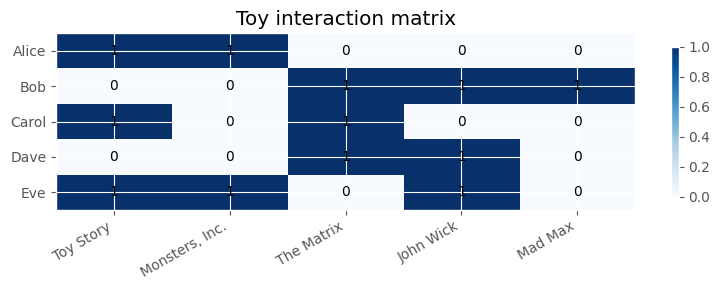

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(interactions.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(items)))
ax.set_xticklabels(items, rotation=30, ha="right")
ax.set_yticks(range(len(users)))
ax.set_yticklabels(users)
ax.set_title("Toy interaction matrix")

for row_idx in range(interactions.shape[0]):
    for col_idx in range(interactions.shape[1]):
        ax.text(col_idx, row_idx, interactions.iloc[row_idx, col_idx], ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()


Что здесь видно даже без модели:

- `Alice` любит семейные / лёгкие фильмы;
- `Bob` любит action / sci-fi блок;
- `Carol` смешанная: у неё есть и `Toy Story`, и `The Matrix`;
- `Dave` ближе к action / sci-fi;
- `Eve` тоже смешанная, но с уклоном в family.

Уже здесь есть намёк на скрытую структуру:
мы можем думать не только в терминах "какие фильмы прямо совпали у пользователей", но и в терминах **скрытых вкусовых осей**.


## 2. Ручная интуиция latent factors

Сначала зададим эти скрытые оси руками.
Пусть у нас есть две latent dimensions:

- `family_affinity`
- `action_affinity`

Это не единственно возможная интерпретация.
Смысл только в том, чтобы увидеть идею:

`score(user, item) = dot(user_factors, item_factors)`


In [4]:
manual_user_factors = pd.DataFrame(
    {
        "family_affinity": [1.0, 0.1, 0.7, 0.1, 0.9],
        "action_affinity": [0.1, 1.1, 0.7, 1.0, 0.5],
    },
    index=users,
)

manual_item_factors = pd.DataFrame(
    {
        "family_affinity": [1.0, 0.9, 0.2, 0.0, 0.1],
        "action_affinity": [0.1, 0.0, 1.0, 1.1, 0.9],
    },
    index=items,
)

manual_scores = manual_user_factors.values @ manual_item_factors.values.T
manual_scores = pd.DataFrame(manual_scores, index=users, columns=items)

print("User factors")
display(manual_user_factors)
print("Item factors")
display(manual_item_factors)
print("Dot-product scores")
display(manual_scores)


User factors


,family_affinity,action_affinity
Alice,1.000,0.100
Bob,0.100,1.100
Carol,0.700,0.700
Dave,0.100,1.000
Eve,0.900,0.500


Item factors


,family_affinity,action_affinity
Toy Story,1.000,0.100
"Monsters, Inc.",0.900,0.000
The Matrix,0.200,1.000
John Wick,0.000,1.100
Mad Max,0.100,0.900


Dot-product scores


,Toy Story,"Monsters, Inc.",The Matrix,John Wick,Mad Max
Alice,1.010,0.900,0.300,0.110,0.190
Bob,0.210,0.090,1.120,1.210,1.000
Carol,0.770,0.630,0.840,0.770,0.700
Dave,0.200,0.090,1.020,1.100,0.910
Eve,0.950,0.810,0.680,0.550,0.540


In [5]:
def recommend_unseen(score_matrix: pd.DataFrame, seen_matrix: pd.DataFrame, user_id: str, top_k: int = 3) -> pd.DataFrame:
    candidate_scores = score_matrix.loc[user_id].copy()
    seen_items = seen_matrix.columns[seen_matrix.loc[user_id] > 0]
    candidate_scores = candidate_scores.drop(index=seen_items)
    ranked = candidate_scores.sort_values(ascending=False).head(top_k)
    return ranked.rename("score").to_frame()


for user_id in users:
    print(f"Top unseen recommendations for {user_id}")
    display(recommend_unseen(manual_scores, interactions, user_id))


Top unseen recommendations for Alice


,score
The Matrix,0.300
Mad Max,0.190
John Wick,0.110


Top unseen recommendations for Bob


,score
Toy Story,0.210
"Monsters, Inc.",0.090


Top unseen recommendations for Carol


,score
John Wick,0.770
Mad Max,0.700
"Monsters, Inc.",0.630


Top unseen recommendations for Dave


,score
Mad Max,0.910
Toy Story,0.200
"Monsters, Inc.",0.090


Top unseen recommendations for Eve


,score
The Matrix,0.680
Mad Max,0.540


Что важно заметить:

- мы вообще не использовали явную логику `item-item neighbours`;
- вместо этого каждый пользователь и каждый объект описываются коротким вектором;
- score получается как совместимость двух векторов;
- даже смешанные пользователи вроде `Carol` и `Eve` естественно описываются комбинацией скрытых факторов.

Это и есть центральная интуиция factorization-подходов.


## 3. А если факторы не задавать руками?

В реальной модели мы не хотим вручную придумывать `family_affinity` и `action_affinity`.
Нам нужно, чтобы модель **нашла** удобные скрытые представления сама.

Один из простейших способов увидеть эту идею на toy-матрице:

- взять матрицу взаимодействий;
- найти её low-rank приближение;
- разложить её на user и item factors.

Ниже не `ALS`, а просто визуально понятный шаг через `SVD`.
Но идея очень близкая: найти компактные скрытые представления, из которых можно восстановить полезные score'ы.


In [6]:
interaction_matrix = interactions.values.astype(float)
u_matrix, singular_values, vt_matrix = np.linalg.svd(interaction_matrix, full_matrices=False)

k = 2
sqrt_s = np.sqrt(np.diag(singular_values[:k]))
learned_user_factors = u_matrix[:, :k] @ sqrt_s
learned_item_factors = vt_matrix[:k, :].T @ sqrt_s

# Знаки факторов в SVD произвольны. Для чтения графика чуть выровняем оси.
if learned_item_factors[items.index("Toy Story"), 0] < 0:
    learned_user_factors[:, 0] *= -1
    learned_item_factors[:, 0] *= -1

if learned_item_factors[items.index("John Wick"), 1] < 0:
    learned_user_factors[:, 1] *= -1
    learned_item_factors[:, 1] *= -1

learned_user_factors = pd.DataFrame(
    learned_user_factors,
    index=users,
    columns=["latent_dim_1", "latent_dim_2"],
)
learned_item_factors = pd.DataFrame(
    learned_item_factors,
    index=items,
    columns=["latent_dim_1", "latent_dim_2"],
)

reconstructed_scores = learned_user_factors.values @ learned_item_factors.values.T
reconstructed_scores = pd.DataFrame(reconstructed_scores, index=users, columns=items)

print("Learned user factors")
display(learned_user_factors)
print("Learned item factors")
display(learned_item_factors)
print("Low-rank reconstructed scores")
display(reconstructed_scores)


Learned user factors


,latent_dim_1,latent_dim_2
Alice,0.524,-0.801
Bob,0.804,0.763
Carol,0.632,-0.058
Dave,0.682,0.549
Eve,0.884,-0.602


Learned item factors


,latent_dim_1,latent_dim_2
Toy Story,0.795,-0.772
"Monsters, Inc.",0.549,-0.742
The Matrix,0.825,0.664
John Wick,0.924,0.376
Mad Max,0.313,0.403


Low-rank reconstructed scores


,Toy Story,"Monsters, Inc.",The Matrix,John Wick,Mad Max
Alice,1.035,0.881,-0.099,0.183,-0.159
Bob,0.050,-0.125,1.170,1.029,0.560
Carol,0.546,0.389,0.483,0.562,0.175
Dave,0.118,-0.034,0.927,0.836,0.435
Eve,1.168,0.932,0.330,0.590,0.034


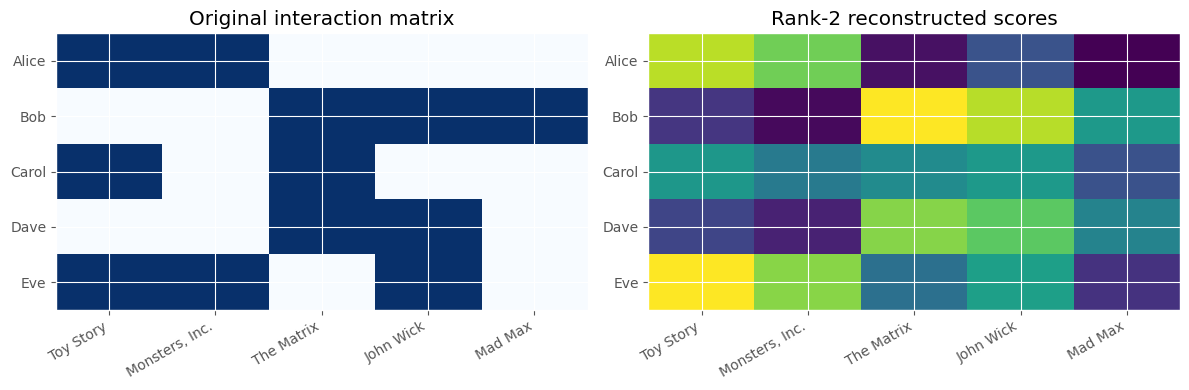

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(interactions.values, cmap="Blues", aspect="auto")
axes[0].set_title("Original interaction matrix")
axes[0].set_xticks(range(len(items)))
axes[0].set_xticklabels(items, rotation=30, ha="right")
axes[0].set_yticks(range(len(users)))
axes[0].set_yticklabels(users)

axes[1].imshow(reconstructed_scores.values, cmap="viridis", aspect="auto")
axes[1].set_title("Rank-2 reconstructed scores")
axes[1].set_xticks(range(len(items)))
axes[1].set_xticklabels(items, rotation=30, ha="right")
axes[1].set_yticks(range(len(users)))
axes[1].set_yticklabels(users)

plt.tight_layout()
plt.show()


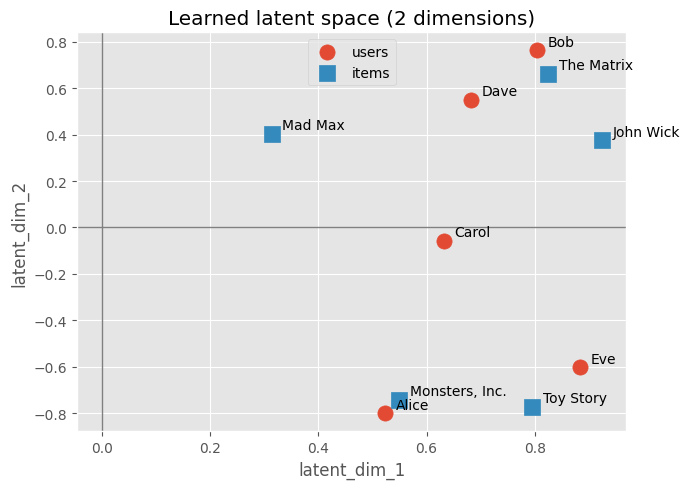

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(learned_user_factors["latent_dim_1"], learned_user_factors["latent_dim_2"], s=120, label="users")
for label, row in learned_user_factors.iterrows():
    ax.text(row["latent_dim_1"] + 0.02, row["latent_dim_2"] + 0.02, label)

ax.scatter(
    learned_item_factors["latent_dim_1"],
    learned_item_factors["latent_dim_2"],
    s=120,
    marker="s",
    label="items",
)
for label, row in learned_item_factors.iterrows():
    ax.text(row["latent_dim_1"] + 0.02, row["latent_dim_2"] + 0.02, label)

ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Learned latent space (2 dimensions)")
ax.set_xlabel("latent_dim_1")
ax.set_ylabel("latent_dim_2")
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
for user_id in users:
    print(f"Top unseen recommendations from learned factors for {user_id}")
    display(recommend_unseen(reconstructed_scores, interactions, user_id))


Top unseen recommendations from learned factors for Alice


,score
John Wick,0.183
The Matrix,-0.099
Mad Max,-0.159


Top unseen recommendations from learned factors for Bob


,score
Toy Story,0.050
"Monsters, Inc.",-0.125


Top unseen recommendations from learned factors for Carol


,score
John Wick,0.562
"Monsters, Inc.",0.389
Mad Max,0.175


Top unseen recommendations from learned factors for Dave


,score
Mad Max,0.435
Toy Story,0.118
"Monsters, Inc.",-0.034


Top unseen recommendations from learned factors for Eve


,score
The Matrix,0.330
Mad Max,0.034


Что здесь важно понять правильно:

- latent dimensions не обязаны называться `family` и `action` буквально;
- модель сама ищет удобные скрытые оси, а человек уже потом пытается их интерпретировать;
- low-rank reconstruction не копирует матрицу идеально, а **сжимает** её в компактное представление;
- за счёт этого можно оценивать и unseen user-item пары, даже если прямого взаимодействия не было;
- отрицательный score в таком toy-примере не означает явный negative label: здесь важнее относительный порядок кандидатов для одного пользователя, чем знак и абсолютная величина score.


## 4. Как это связано с ALS

Теперь можно сформулировать главный мост к следующему notebook.

`ALS` делает не магию и не "ещё одну случайную модель".
Он решает гораздо более практическую задачу:

- найти user factors;
- найти item factors;
- сделать это не на toy-матрице, а на реальных данных;
- учесть sparse interactions и регуляризацию;
- получить полезные recommendation scores для unseen объектов.

То есть после этого notebook должно остаться простое понимание:

- `item-item CF` работает через похожесть соседей;
- factorization работает через скрытые представления пользователей и объектов;
- `ALS` — это один из практических способов такие представления обучать.

Следующий шаг: [01_als_implicit.ipynb](../../notebooks/advanced/01_als_implicit.ipynb).
